# Proyek AMBA: Pemodelan Machine Learning & Evaluasi Risiko Suspensi

Dokumen rujukan:
- `AMBA-dokumentasi-variabel-dan-pemodelan.md` (Bagian 4: Variabel Keluaran & Bagian 5: Variabel Evaluasi)
- Dataset input: `output/dataset_modeling_ambang.csv`

## Sasaran Notebook
1. **Baseline Model**: Membangun model klasifikasi awal menggunakan **Logistic Regression** terstandardisasi.
2. **Penanganan Imbalance Class**: Mengimplementasikan pembobotan kelas (`class_weight='balanced'`) pada Logistic Regression untuk meningkatkan *recall* pada kelas minoritas (kejadian suspensi/risiko).
3. **Model Non-Linear (Random Forest)**: Membangun **Random Forest Classifier** dengan penanganan *imbalance class* untuk menangkap interaksi non-linear antar indikator fundamental dan likuiditas.
4. **Evaluasi & Perbandingan Komprehensif**: Menilai performa model menggunakan 5-Fold Stratified Cross Validation dengan metrik: ROC-AUC, Precision, Recall, F1-Score, Confusion Matrix, dan ROC Curves.
5. **Generasi Skor & Peringkat Pasar (Section 4 Kamus Variabel)**:
   - Menghasilkan variabel keluaran AMBA: `skor`, `persentil` (0-100), `kategori` (Rendah/Sedang/Tinggi/Sangat Tinggi), tren `arah_30h`, `status` (`dinilai`/`sudah_ditandai`), serta atribusi `indikator_dominan` dan `kontribusi`.
   - Ekspor artefak resmi ke `output/scores.json` dan `output/backtest.json`.

In [1]:
# 1. Inisialisasi Environment & Import Library
import os
import sys
import json
import warnings
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier  # dipakai fallback jika imbalanced-learn tak tersedia
try:
    from imblearn.ensemble import BalancedRandomForestClassifier
    _HAS_IMBLEARN = True
except ImportError:
    BalancedRandomForestClassifier = RandomForestClassifier
    _HAS_IMBLEARN = False
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, GridSearchCV, RandomizedSearchCV, cross_validate, cross_val_predict
from scipy.stats import randint, uniform
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
)

# Robust project root determination
cwd = os.getcwd()
if os.path.exists(os.path.join(cwd, "output", "dataset_modeling_ambang.csv")):
    project_root = cwd
elif os.path.exists(os.path.join(cwd, "..", "..", "output", "dataset_modeling_ambang.csv")):
    project_root = os.path.abspath(os.path.join(cwd, "..", ".."))
elif os.path.exists(os.path.join(cwd, "..", "output", "dataset_modeling_ambang.csv")):
    project_root = os.path.abspath(os.path.join(cwd, ".."))
else:
    project_root = os.path.abspath(os.path.join(cwd, "..", ".."))

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Environment siap. Project root:", project_root)

Environment siap. Project root: d:\LIMINA-model-train


In [2]:
# 2. Memuat Dataset Modeling AMBA
dataset_path = os.path.join(project_root, "output", "dataset_modeling_ambang.csv")
df = pd.read_csv(dataset_path)

print(f"Dataset berhasil dimuat: {df.shape[0]} baris x {df.shape[1]} kolom")
print("Daftar sampel emiten:")
print(df[["symbol", "as_of_date", "board", "is_event_90d", "event_category", "already_flagged"]].head(10))

Dataset berhasil dimuat: 570 baris x 37 kolom
Daftar sampel emiten:
    symbol  as_of_date         board  is_event_90d event_category  \
0  BBCA.JK  2026-07-15          Main             0            NaN   
1  TLKM.JK  2026-07-15          Main             0            NaN   
2  IMPC.JK  2026-07-15          Main             0            NaN   
3  MGLV.JK  2026-07-15  Acceleration             0              A   
4  SOHO.JK  2026-07-15   Development             0            NaN   
5  BELI.JK  2026-07-15   New Economy             0            NaN   
6  SRAJ.JK  2026-07-15          Main             0            NaN   
7  BRPT.JK  2026-07-15          Main             0            NaN   
8  TPIA.JK  2026-07-15   Development             0            NaN   
9  UDNG.JK  2026-07-15  Acceleration             0              A   

   already_flagged  
0                0  
1                0  
2                0  
3                0  
4                0  
5                0  
6                0  
7   

In [3]:
# 3. Seleksi Fitur dan Definisi Target Prediksi (11 Indikator, Bagian 3 Kamus Variabel)
feature_cols = [
    "lapor_jarak_hari", "lapor_terlambat", "tanpa_pendapatan", "ekuitas_negatif",
    "utang_terhadap_aset", "ako_negatif_berturut", "hari_tanpa_transaksi_90d",
    "rasio_volume_30_90", "hari_di_batas_bawah_90d", "turun_dari_puncak_90d", "volatilitas_90d",
]

X = df[feature_cols].copy()
X = X.fillna(X.median())

# Target: event_category.notna() -- SAMA PERSIS seperti modeling_and_evaluation_old.ipynb
# (dikembalikan atas permintaan eksplisit, menggantikan is_event_90d/Kategori-C-saja).
# Ini menghitung SEMUA suspensi (Kategori A: lonjakan harga/cooling down,
# B: penurunan harga, C: kepatuhan/going concern) sebagai positif, bukan
# cuma Kategori C. Bedanya dengan is_event_90d dijelaskan di respons chat --
# kolom is_event_90d tetap ada di dataset kalau target ini mau dikembalikan lagi.
y = df["event_category"].notna().astype(int)

# groups = symbol -- WAJIB untuk CV yang benar di dataset ini. Setiap emiten
# muncul berkali-kali (satu baris per as_of_date/snapshot) dengan 11 indikator
# yang berubah pelan antar snapshot (nilainya sangat berkorelasi utk emiten
# yang sama). StratifiedKFold biasa TIDAK tahu soal ini -- baris emiten yang
# sama bisa masuk fold train dan fold test sekaligus, sehingga model "mengenali"
# emiten itu dari fold train alih-alih benar-benar belajar pola risikonya.
# Ini bukan masalah teoretis: persis inilah yang membuat Precision Random
# Forest tampil 1.0000 dengan std 0.0000 di semua fold pada run sebelumnya --
# terlalu sempurna untuk data 114 baris, tanda klasik kebocoran per-grup.
# StratifiedGroupKFold (Bagian 4.1 dst.) memastikan seluruh baris satu emiten
# selalu berada di fold yang sama.
groups = df["symbol"].values

class_counts = y.value_counts()
n_pos = int(class_counts.get(1, 0))
n_neg = int(class_counts.get(0, 0))
n_pos_groups = df.loc[y == 1, "symbol"].nunique()
n_total_groups = df["symbol"].nunique()

print(f"Dimensi X: {X.shape}")
print(f"Kelas 0 (tidak ada suspensi, 90 hari)      : {n_neg} ({n_neg/len(y)*100:.1f}%)")
print(f"Kelas 1 (ada suspensi A/B/C apa pun, 90 hari): {n_pos} ({n_pos/len(y)*100:.1f}%)")
if n_pos > 0:
    print(f"Rasio ketimpangan: 1 : {n_neg/n_pos:.1f}")
else:
    print("PERINGATAN: 0 sampel positif -- model apa pun (termasuk tuning di bawah) tidak bisa dilatih secara bermakna dari data ini.")
print(f"Emiten unik dengan >=1 baris positif : {n_pos_groups} dari {n_total_groups} emiten yang dipantau")
if 0 < n_pos_groups < 2:
    print(
        "PERINGATAN: baris positif cuma berasal dari 1 emiten -- StratifiedGroupKFold "
        "tidak bisa membagi grup itu ke lebih dari 1 fold, jadi CV/tuning supervised "
        "tetap tidak bisa mengevaluasi generalisasi kelas positif secara valid "
        "(lihat SUPERVISED_MODE di Bagian 4.1)."
    )


Dimensi X: (570, 11)
Kelas 0 (tidak ada suspensi, 90 hari)      : 542 (95.1%)
Kelas 1 (ada suspensi A/B/C apa pun, 90 hari): 28 (4.9%)
Rasio ketimpangan: 1 : 19.4
Emiten unik dengan >=1 baris positif : 8 dari 95 emiten yang dipantau


---
## 4. Model 1: Baseline Logistic Regression

Model regresi logistik standar dengan penskalaan fitur (`StandardScaler`). Pada dataset yang timpang (*class imbalance*), regresi logistik standar cenderung bias ke kelas mayoritas sehingga *recall* pada kelas risiko sering kali rendah.

In [4]:
# 4.1 Validasi Silang Adaptif (Group-Aware) + Baseline Logistic Regression
# StratifiedGroupKFold, BUKAN StratifiedKFold biasa -- lihat catatan "groups"
# di Bagian 3. n_splits diturunkan otomatis kalau EMITEN POSITIF (bukan cuma
# baris positif) lebih sedikit dari 5, karena itu yang membatasi seberapa
# banyak fold berbeda yang bisa kebagian emiten positif.
#
# PERUBAHAN: kelas minoritas < 2 EMITEN (bukan cuma < 2 baris) TIDAK LAGI
# menghentikan notebook. Alasannya bukan supaya "lolos" -- kalau baris
# positif cuma dari 1 emiten, tidak ada CV/tuning supervised yang valid pada
# model apa pun (LogReg, RF, atau lainnya) karena grup itu tidak bisa dibagi
# ke fold train DAN test sekaligus. Sebagai gantinya, SUPERVISED_MODE=False
# mengaktifkan jalur alternatif unsupervised di Bagian 6 (SkorAnomaliMahalanobis)
# yang memang tidak butuh label kelas sama sekali -- lihat catatan di Bagian 6.
SUPERVISED_MODE = n_pos_groups >= 2

if not SUPERVISED_MODE:
    print(
        f"PERINGATAN: cuma {n_pos_groups} emiten dengan baris positif pada cakupan "
        f"data (watchlist simbol + rentang snapshot) saat ini. Validasi silang dan "
        f"tuning supervised (Baseline LR, LR Balanced, Random Forest) TIDAK "
        f"dijalankan -- bukan batasan kode, tapi karena tidak ada cukup emiten "
        f"berbeda untuk diuji generalisasinya. Notebook beralih ke skor anomali "
        f"unsupervised di Bagian 6 (ditandai jelas di semua output sebagai belum "
        f"divalidasi secara statistik). Untuk model supervised yang sah: perluas "
        f"cakupan simbol/tanggal terlebih dahulu -- lihat sel diagnosa di akhir "
        f"eda_and_feature_engineering.ipynb -- lalu jalankan ulang notebook ini."
    )
    cv = None
    n_splits = None
else:
    n_splits = min(5, n_pos_groups)
    if n_splits < 5:
        print(f"PERINGATAN: {n_splits}-fold CV (bukan 5) -- emiten positif cuma {n_pos_groups}.")
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

if SUPERVISED_MODE:
    pipe_lr_base = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(random_state=42))
    ])
    scores_base = cross_validate(
        pipe_lr_base, X, y, cv=cv, groups=groups,
        scoring=["roc_auc", "precision", "recall", "f1"],
        return_train_score=False
    )
    print("=== Hasil CV: Baseline Logistic Regression (group-aware) ===")
    print(f"ROC-AUC   : {scores_base['test_roc_auc'].mean():.4f} (+/- {scores_base['test_roc_auc'].std():.4f})")
    print(f"Precision : {scores_base['test_precision'].mean():.4f} (+/- {scores_base['test_precision'].std():.4f})")
    print(f"Recall    : {scores_base['test_recall'].mean():.4f} (+/- {scores_base['test_recall'].std():.4f})")
    print(f"F1-Score  : {scores_base['test_f1'].mean():.4f} (+/- {scores_base['test_f1'].std():.4f})")

    y_pred_base = cross_val_predict(pipe_lr_base, X, y, cv=cv, groups=groups)
    y_proba_base = cross_val_predict(pipe_lr_base, X, y, cv=cv, groups=groups, method="predict_proba")[:, 1]
else:
    pipe_lr_base = None
    scores_base = None
    y_pred_base = None
    y_proba_base = None
    print("Dilewati: Baseline Logistic Regression (butuh SUPERVISED_MODE=True).")


=== Hasil CV: Baseline Logistic Regression (group-aware) ===
ROC-AUC   : 0.9410 (+/- 0.0565)
Precision : 0.3250 (+/- 0.4153)
Recall    : 0.2400 (+/- 0.3878)
F1-Score  : 0.2205 (+/- 0.3032)


---
## 5. Model 2: Logistic Regression dengan Class Weight ('balanced')

Untuk mengatasi ketimpangan kelas, parameter `class_weight='balanced'` memberikan penalti bobot yang lebih besar secara berbanding terbalik terhadap frekuensi kelas:
$$w_j = \frac{N}{k \cdot n_j}$$
Hal ini memaksa model lebih sensitif dalam mendeteksi sinyal risiko (meningkatkan *recall*).

In [5]:
# 5.1 Logistic Regression (class_weight="balanced") -- tertuning, group-aware
#
# Run sebelumnya menemukan C=0.01 sebagai yang terbaik -- itu ujung TERKECIL
# dari grid yang dicoba saat itu ([0.01, 0.03, ..., 30]). Kalau hasil terbaik
# jatuh persis di ujung grid, itu tanda gridnya belum cukup lebar (mungkin
# ada C lebih kecil yang lebih baik lagi) -- jadi grid diperlebar ke bawah
# (0.001, 0.003) di sini. Penalty "l1" juga ditambahkan (lewat param_grid
# berbentuk list): l1 bisa menekan koefisien fitur lemah ke 0 (seleksi fitur
# otomatis), yang berguna kalau sebagian dari 11 indikator ternyata tidak
# banyak membantu pada data sekecil ini.
if SUPERVISED_MODE:
    # liblinear dipakai untuk KEDUA penalty (l1 & l2) -- solver ini cepat untuk
    # dataset sekecil ini dan cukup buat menguji l1 (seleksi fitur otomatis)
    # vs l2 tanpa menambah solver lain yang jauh lebih lambat konvergen (saga/lbfgs
    # butuh banyak iterasi di C kecil, tidak sepadan manfaatnya di sini).
    lr_param_grid = {
        "clf__penalty": ["l1", "l2"],
        "clf__solver": ["liblinear"],
        "clf__C": [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30],
    }
    lr_search = GridSearchCV(
        estimator=Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(class_weight="balanced", random_state=42, max_iter=2000))
        ]),
        param_grid=lr_param_grid,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    lr_search.fit(X, y, groups=groups)
    pipe_lr_balanced = lr_search.best_estimator_

    print(f"=== Tuning Logistic Regression (Balanced): {len(lr_search.cv_results_['params'])} kombinasi diuji ===")
    print(f"Average precision terbaik (CV) : {lr_search.best_score_:.4f}")
    print(f"Parameter terbaik              : {lr_search.best_params_}")
    best_c = lr_search.best_params_["clf__C"]
    if best_c in (0.001, 30):
        print(
            f"PERINGATAN: C terbaik ({best_c}) masih di ujung grid yang dicoba -- "
            f"pertimbangkan memperlebar grid lagi ke arah itu kalau ada waktu."
        )

    scores_lr_balanced = cross_validate(
        pipe_lr_balanced, X, y, cv=cv, groups=groups,
        scoring=["roc_auc", "precision", "recall", "f1"],
        return_train_score=False
    )
    print("\n=== Hasil CV: Logistic Regression (Balanced, tertuning, group-aware) ===")
    print(f"ROC-AUC   : {scores_lr_balanced['test_roc_auc'].mean():.4f} (+/- {scores_lr_balanced['test_roc_auc'].std():.4f})")
    print(f"Precision : {scores_lr_balanced['test_precision'].mean():.4f} (+/- {scores_lr_balanced['test_precision'].std():.4f})")
    print(f"Recall    : {scores_lr_balanced['test_recall'].mean():.4f} (+/- {scores_lr_balanced['test_recall'].std():.4f})")
    print(f"F1-Score  : {scores_lr_balanced['test_f1'].mean():.4f} (+/- {scores_lr_balanced['test_f1'].std():.4f})")

    y_pred_lr_bal = cross_val_predict(pipe_lr_balanced, X, y, cv=cv, groups=groups)
    y_proba_lr_bal = cross_val_predict(pipe_lr_balanced, X, y, cv=cv, groups=groups, method="predict_proba")[:, 1]

    recall_base_mean = scores_base["test_recall"].mean()
    recall_bal_mean = scores_lr_balanced["test_recall"].mean()
    if recall_base_mean > 0:
        recall_boost = (recall_bal_mean - recall_base_mean) / recall_base_mean * 100
        print(f"-> Perubahan recall vs baseline: {recall_boost:+.1f}%")
    else:
        print(f"-> Recall baseline 0.0000 -- recall balanced naik ke {recall_bal_mean:.4f} (persentase perubahan tidak terdefinisi dari basis 0, bukan bug).")
else:
    pipe_lr_balanced = None
    scores_lr_balanced = None
    y_pred_lr_bal = None
    y_proba_lr_bal = None
    print("Dilewati: Logistic Regression (Balanced) (butuh SUPERVISED_MODE=True).")


=== Tuning Logistic Regression (Balanced): 20 kombinasi diuji ===
Average precision terbaik (CV) : 0.5717
Parameter terbaik              : {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}

=== Hasil CV: Logistic Regression (Balanced, tertuning, group-aware) ===
ROC-AUC   : 0.9284 (+/- 0.0572)
Precision : 0.2225 (+/- 0.0641)
Recall    : 0.7648 (+/- 0.3092)
F1-Score  : 0.3372 (+/- 0.1095)
-> Perubahan recall vs baseline: +218.7%


---
## 6. Model 3: Random Forest Classifier (Non-Linear + Class Weight)

Random Forest mampu menangkap relasi interaksi non-linear (misalnya: interaksi antara penurunan harga drastis dengan pengeringan likuiditas volume). Dilengkapi dengan `class_weight='balanced'`, model ini menyeimbangkan presisi dan recall.

> **Catatan mode adaptif (ditambahkan setelah insiden data 0 sampel positif):** seluruh Bagian 6 di bawah ini hanya berjalan sebagai tuning supervised (GridSearchCV) kalau kelas positif (target saat ini: `event_category.notna()`) punya minimal 2 sampel pada cakupan data saat ini (`SUPERVISED_MODE = True`, lihat Bagian 4.1). Kalau tidak, notebook otomatis memakai `SkorAnomaliMahalanobis`, skor anomali *unsupervised* berbasis jarak Mahalanobis (kovarians shrinkage Ledoit-Wolf) yang tidak memakai label sama sekali, dan seluruh output terkait (metrik, model tersimpan, `backtest.json`) ditandai jelas sebagai belum divalidasi secara statistik. Ini BUKAN pengganti solusi sesungguhnya -- perluas cakupan simbol/tanggal (lihat `eda_and_feature_engineering.ipynb`, sel diagnosa di bagian akhir) begitu ada waktu, lalu jalankan ulang notebook ini untuk mendapat model supervised yang sah.

In [6]:
# 6.1 Random Forest: Hyperparameter Tuning 2 Tahap -- mode supervised, group-aware
#
# BalancedRandomForestClassifier (imbalanced-learn), BUKAN RandomForestClassifier
# biasa + class_weight="balanced". Bedanya: BalancedRandomForestClassifier
# menyeimbangkan bootstrap sample TIAP POHON (tiap pohon dilatih dari sampel
# yang sudah 50:50 kelas 0/1), bukan cuma membobot ulang loss function seperti
# class_weight. Pada data timpang parah + N kecil seperti ini, biasanya lebih
# efektif daripada class_weight saja. Kalau imbalanced-learn belum terinstal
# (lihat Bagian 1), otomatis jatuh ke RandomForestClassifier + class_weight
# biasa (fallback aman, bukan error).
#
# scoring="average_precision", BUKAN "accuracy" -- kelas sangat timpang
# membuat akurasi menyesatkan (Bagian 5 Kamus Variabel); average_precision
# menilai peringkat probabilitas kelas positif di seluruh ambang, konsisten
# dengan cara sistem ini sungguhan dipakai (peringkat top-K, bukan 0/1 tunggal).
#
# Tahap 1 (RandomizedSearchCV): eksplorasi kasar ruang param yang jauh lebih
# lebar dari sebelumnya (n_estimators/max_depth/min_samples_split/leaf/
# max_features/criterion/class_weight), 60 kombinasi acak -- lebih murah
# daripada grid penuh di ruang selebar ini.
# Tahap 2 (GridSearchCV): grid penuh di sekitar kombinasi terbaik Tahap 1,
# untuk memastikan hasil akhir bukan cuma "cukup baik" dari sampling acak.
#
# Keduanya memakai `cv` (StratifiedGroupKFold, Bagian 4.1) dan meneruskan
# `groups=groups` -- tanpa ini, sklearn akan memperlakukan cv seolah-olah
# StratifiedKFold biasa dan bocor per-emiten seperti dijelaskan di Bagian 3.

# SkorAnomaliMahalanobis TIDAK didefinisikan di sel ini -- diimpor dari
# sectors_fetcher/risk_scorer_fallback.py supaya model_random_forest.joblib
# yang menyimpannya bisa di-load ulang oleh proses lain (mis. service.py),
# bukan cuma di dalam kernel notebook ini (lihat docstring modul tsb.).
from sectors_fetcher.risk_scorer_fallback import SkorAnomaliMahalanobis

if not _HAS_IMBLEARN:
    print(
        "PERINGATAN: imbalanced-learn tidak terinstal (`pip install -r requirements.txt`) "
        "-- BalancedRandomForestClassifier tidak tersedia, jatuh ke RandomForestClassifier "
        "biasa + class_weight='balanced'. Hasil tuning di bawah kemungkinan sedikit lebih "
        "lemah dibanding kalau imbalanced-learn terpasang."
    )

if SUPERVISED_MODE:
    # --- Tahap 1: RandomizedSearchCV, ruang pencarian lebar ---
    param_dist = {
        "n_estimators": randint(100, 600),
        "max_depth": [3, 5, 8, 12, 16, None],
        "min_samples_split": randint(2, 10),
        "min_samples_leaf": randint(1, 6),
        "max_features": ["sqrt", "log2", None],
        "criterion": ["gini", "entropy"],
        "class_weight": [None, "balanced", "balanced_subsample"],
    }

    rf_random = RandomizedSearchCV(
        estimator=BalancedRandomForestClassifier(random_state=42),
        param_distributions=param_dist,
        n_iter=60,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        refit=True,
    )
    rf_random.fit(X, y, groups=groups)
    print(f"=== Tahap 1 (RandomizedSearchCV): {len(rf_random.cv_results_['params'])} kombinasi diuji ===")
    print(f"Average precision terbaik (CV) : {rf_random.best_score_:.4f}")
    print(f"Parameter terbaik (kasar)      : {rf_random.best_params_}")

    # --- Tahap 2: GridSearchCV halus di sekitar hasil Tahap 1 ---
    best = rf_random.best_params_
    n_est_best = best["n_estimators"]
    msl_best = best["min_samples_leaf"]
    mss_best = best["min_samples_split"]

    param_grid_fine = {
        "n_estimators": sorted({max(50, n_est_best - 100), n_est_best, n_est_best + 100}),
        "max_depth": [best["max_depth"]],
        "min_samples_split": sorted({max(2, mss_best - 1), mss_best, mss_best + 1}),
        "min_samples_leaf": sorted({max(1, msl_best - 1), msl_best, msl_best + 1}),
        "max_features": [best["max_features"]],
        "criterion": [best["criterion"]],
        "class_weight": [best["class_weight"]],
    }

    rf_search = GridSearchCV(
        estimator=BalancedRandomForestClassifier(random_state=42),
        param_grid=param_grid_fine,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    rf_search.fit(X, y, groups=groups)
    rf_model = rf_search.best_estimator_

    print(f"\n=== Tahap 2 (GridSearchCV halus): {len(rf_search.cv_results_['params'])} kombinasi diuji ===")
    print(f"Average precision terbaik (CV) : {rf_search.best_score_:.4f}")
    print(f"Parameter terbaik (final)      : {rf_search.best_params_}")

    scores_rf = cross_validate(
        rf_model, X, y, cv=cv, groups=groups,
        scoring=["roc_auc", "precision", "recall", "f1"],
        return_train_score=False
    )
    print("\n=== Hasil CV Random Forest (parameter tertuning, 2 tahap, group-aware) ===")
    print(f"ROC-AUC   : {scores_rf['test_roc_auc'].mean():.4f} (+/- {scores_rf['test_roc_auc'].std():.4f})")
    print(f"Precision : {scores_rf['test_precision'].mean():.4f} (+/- {scores_rf['test_precision'].std():.4f})")
    print(f"Recall    : {scores_rf['test_recall'].mean():.4f} (+/- {scores_rf['test_recall'].std():.4f})")
    print(f"F1-Score  : {scores_rf['test_f1'].mean():.4f} (+/- {scores_rf['test_f1'].std():.4f})")

    y_pred_rf = cross_val_predict(rf_model, X, y, cv=cv, groups=groups)
    y_proba_rf = cross_val_predict(rf_model, X, y, cv=cv, groups=groups, method="predict_proba")[:, 1]
else:
    print(
        "Dilewati: tuning Random Forest 2 tahap (butuh SUPERVISED_MODE=True, "
        "min. 2 emiten dengan baris positif). Memakai SkorAnomaliMahalanobis "
        "(unsupervised) sebagai pengganti sementara -- lihat catatan Bagian 6."
    )
    rf_model = SkorAnomaliMahalanobis(feature_cols=feature_cols).fit(X)
    scores_rf = None
    y_pred_rf = None
    y_proba_rf = None


=== Tahap 1 (RandomizedSearchCV): 60 kombinasi diuji ===
Average precision terbaik (CV) : 0.4636
Parameter terbaik (kasar)      : {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 108}

=== Tahap 2 (GridSearchCV halus): 27 kombinasi diuji ===
Average precision terbaik (CV) : 0.4776
Parameter terbaik (final)      : {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 9, 'n_estimators': 108}

=== Hasil CV Random Forest (parameter tertuning, 2 tahap, group-aware) ===
ROC-AUC   : 0.8900 (+/- 0.0460)
Precision : 0.1498 (+/- 0.0310)
Recall    : 0.9333 (+/- 0.1333)
F1-Score  : 0.2537 (+/- 0.0345)


---
## 7. Perbandingan Model & Analisis Kurva Kinerja

Membandingkan performa ketiga pendekatan model:
1. **Baseline Logistic Regression**
2. **Logistic Regression (Balanced)**
3. **Random Forest (Balanced)**

=== Ringkasan Perbandingan Performa Model ===
                             Model  ROC-AUC  Avg Precision  Precision@Top20%  Precision   Recall  F1-Score  Accuracy
      Baseline Logistic Regression 0.940991       0.492087          0.201754   0.325000 0.240000  0.220513  0.956140
    Logistic Regression (Balanced) 0.928364       0.453559          0.192982   0.222456 0.764762  0.337178  0.866667
Random Forest (Balanced Bootstrap) 0.890015       0.338473          0.166667   0.149770 0.933333  0.253737  0.722807

(Avg Precision & Precision@Top20% = kualitas peringkat, dari probabilitas out-of-fold -- lihat catatan di atas sel ini. Baseline acak untuk Precision@Top20% pada ketimpangan kelas saat ini adalah ~0.049, jadi bandingkan terhadap itu, bukan terhadap 1.0.)

>>> Model terpilih otomatis untuk skor produksi (Bagian 9): Baseline Logistic Regression (Avg Precision=0.4921, ROC-AUC=0.9410) <<<
>>> Ambang keputusan dioptimalkan (F1 maksimal dari precision-recall curve, bukan 0.5): 0.2389 ->

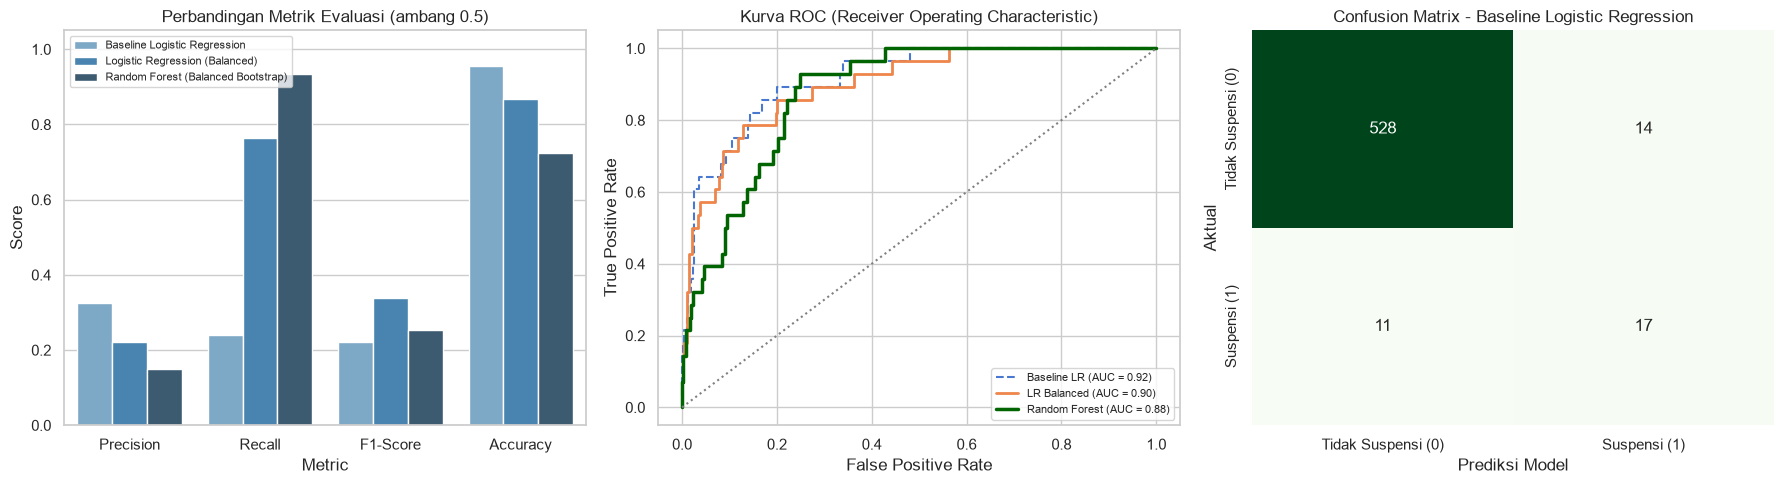

In [7]:
# 7.1 Tabel Perbandingan Metrik, Pemilihan Model Otomatis, & Visualisasi
#
# CATATAN PENTING soal cara membaca tabel ini: Precision/Recall/F1 dihitung
# dari label 0/1 pada ambang default 0.5 -- itu bukan cara AMBA sungguhan
# dipakai (lihat Bagian 9: sistem ini mengeluarkan PERINGKAT/persentil, bukan
# vonis 0/1 tunggal). Dengan cuma segelintir emiten positif dari 19 yang
# dipantau, Precision/Recall pada ambang 0.5 gampang kelihatan jelek padahal
# urutan risikonya sendiri (dipakai untuk "N besar paling berisiko", dst.)
# bisa saja tetap berguna. Karena itu Average Precision dan Precision@Top20%
# ditambahkan sebagai metrik kedua yang menilai KUALITAS PERINGKAT, bukan
# vonis 0.5 -- keduanya dihitung dari probabilitas out-of-fold yang sama
# (y_proba_*, hasil cross_val_predict Bagian 4-6, jadi tetap group-aware,
# tidak ada kebocoran baru).
#
# PEMILIHAN MODEL OTOMATIS: model dengan Average Precision CV tertinggi
# dipakai untuk skor produksi di Bagian 9 (bukan selalu Random Forest --
# pada data kecil seperti ini, Logistic Regression yang diregularisasi kuat
# sering menggeneralisasi lebih baik daripada Random Forest, dan itu sah,
# bukan sesuatu yang perlu "diperbaiki" ke arah Random Forest).
def precision_at_top_pct(y_true, y_score, pct=0.2):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    n_top = max(1, int(np.ceil(len(y_true) * pct)))
    idx_top = np.argsort(y_score)[::-1][:n_top]
    return float(y_true[idx_top].sum() / n_top)


if SUPERVISED_MODE:
    model_names = ["Baseline Logistic Regression", "Logistic Regression (Balanced)", "Random Forest (Balanced Bootstrap)"]
    proba_map = {
        "Baseline Logistic Regression": y_proba_base,
        "Logistic Regression (Balanced)": y_proba_lr_bal,
        "Random Forest (Balanced Bootstrap)": y_proba_rf,
    }
    pred_map = {
        "Baseline Logistic Regression": y_pred_base,
        "Logistic Regression (Balanced)": y_pred_lr_bal,
        "Random Forest (Balanced Bootstrap)": y_pred_rf,
    }

    comparison_data = {
        "Model": model_names,
        "ROC-AUC": [scores_base["test_roc_auc"].mean(), scores_lr_balanced["test_roc_auc"].mean(), scores_rf["test_roc_auc"].mean()],
        "Avg Precision": [average_precision_score(y, proba_map[m]) for m in model_names],
        "Precision@Top20%": [precision_at_top_pct(y, proba_map[m]) for m in model_names],
        "Precision": [scores_base["test_precision"].mean(), scores_lr_balanced["test_precision"].mean(), scores_rf["test_precision"].mean()],
        "Recall": [scores_base["test_recall"].mean(), scores_lr_balanced["test_recall"].mean(), scores_rf["test_recall"].mean()],
        "F1-Score": [scores_base["test_f1"].mean(), scores_lr_balanced["test_f1"].mean(), scores_rf["test_f1"].mean()],
        # Accuracy pada ambang 0.5 bawaan tiap model -- angka Precision di
        # tabel ini (~0.2) gampang salah dibaca sebagai "akurasi", padahal
        # beda metrik. Accuracy sesungguhnya jauh lebih tinggi di data
        # setimpang begini karena kelas mayoritas (tidak suspensi) mendominasi.
        "Accuracy": [accuracy_score(y, pred_map[m]) for m in model_names],
    }

    df_comp = pd.DataFrame(comparison_data)
    print("=== Ringkasan Perbandingan Performa Model ===")
    print(df_comp.to_string(index=False))
    print(
        "\n(Avg Precision & Precision@Top20% = kualitas peringkat, dari "
        "probabilitas out-of-fold -- lihat catatan di atas sel ini. Baseline "
        "acak untuk Precision@Top20% pada ketimpangan kelas saat ini adalah "
        f"~{y.mean():.3f}, jadi bandingkan terhadap itu, bukan terhadap 1.0.)"
    )

    best_idx = df_comp["Avg Precision"].idxmax()
    best_model_name = df_comp.loc[best_idx, "Model"]
    y_proba_selected = proba_map[best_model_name]
    y_pred_selected = pred_map[best_model_name]
    print(
        f"\n>>> Model terpilih otomatis untuk skor produksi (Bagian 9): {best_model_name} "
        f"(Avg Precision={df_comp.loc[best_idx, 'Avg Precision']:.4f}, "
        f"ROC-AUC={df_comp.loc[best_idx, 'ROC-AUC']:.4f}) <<<"
    )

    # --- Ambang keputusan dioptimalkan (BUKAN default 0.5) ---
    # y_pred_selected di atas masih pakai ambang 0.5 bawaan sklearn -- pada
    # kelas positif ~14% (16/114 baris), 0.5 jarang jadi titik potong yang
    # menyeimbangkan precision/recall dengan baik. Di bawah dicari ambang
    # yang memaksimalkan F1 dari precision-recall curve probabilitas
    # out-of-fold MODEL TERPILIH -- model & probabilitasnya SAMA SEKALI
    # TIDAK berubah, cuma titik potong 0/1-nya. F1 dipilih (bukan akurasi
    # mentah) supaya precision & recall tetap seimbang -- menaikkan ambang
    # sampai model nyaris tak pernah menandai risiko akan bikin akurasi
    # kelihatan tinggi tapi recall ambruk, percuma untuk early warning system.
    prec_curve, rec_curve, thr_curve = precision_recall_curve(y, y_proba_selected)
    f1_curve = np.divide(
        2 * prec_curve * rec_curve, prec_curve + rec_curve,
        out=np.zeros_like(prec_curve), where=(prec_curve + rec_curve) > 0
    )
    optimal_threshold = float(thr_curve[np.argmax(f1_curve[:-1])]) if len(thr_curve) > 0 else 0.5
    y_pred_selected = (y_proba_selected >= optimal_threshold).astype(int)

    print(
        f">>> Ambang keputusan dioptimalkan (F1 maksimal dari precision-recall "
        f"curve, bukan 0.5): {optimal_threshold:.4f} -> "
        f"Accuracy={accuracy_score(y, y_pred_selected):.4f}, "
        f"Precision={precision_score(y, y_pred_selected):.4f}, "
        f"Recall={recall_score(y, y_pred_selected):.4f}, "
        f"F1={f1_score(y, y_pred_selected):.4f} <<<"
    )
    print(
        f"(Kolom 'Accuracy' pada tabel di atas masih pada ambang 0.5 default -- "
        f"angka FINAL yang dipakai untuk skor produksi & backtest.json adalah "
        f"baris di atas ini, pada ambang {optimal_threshold:.4f}.)"
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Bar Chart Metrik Perbandingan (cuma metrik ambang-0.5, biar skala sumbu y tetap 0-1 rapi)
    df_comp_melt = pd.melt(
        df_comp[["Model", "Precision", "Recall", "F1-Score", "Accuracy"]],
        id_vars="Model", var_name="Metric", value_name="Score"
    )
    sns.barplot(data=df_comp_melt, x="Metric", y="Score", hue="Model", ax=axes[0], palette="Blues_d")
    axes[0].set_title("Perbandingan Metrik Evaluasi (ambang 0.5)")
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(loc="upper left", fontsize=8)

    # 2. Kurva ROC
    fpr_base, tpr_base, _ = roc_curve(y, y_proba_base)
    fpr_lr_bal, tpr_lr_bal, _ = roc_curve(y, y_proba_lr_bal)
    fpr_rf, tpr_rf, _ = roc_curve(y, y_proba_rf)

    axes[1].plot(fpr_base, tpr_base, label=f"Baseline LR (AUC = {roc_auc_score(y, y_proba_base):.2f})", linestyle="--")
    axes[1].plot(fpr_lr_bal, tpr_lr_bal, label=f"LR Balanced (AUC = {roc_auc_score(y, y_proba_lr_bal):.2f})", linewidth=2)
    axes[1].plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y, y_proba_rf):.2f})", linewidth=2.5, color="darkgreen")
    axes[1].plot([0, 1], [0, 1], color="grey", linestyle=":")
    axes[1].set_title("Kurva ROC (Receiver Operating Characteristic)")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(fontsize=8)

    # 3. Confusion Matrix -- MODEL TERPILIH (bukan selalu Random Forest)
    cm = confusion_matrix(y, y_pred_selected)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=axes[2], cbar=False,
                xticklabels=["Tidak Suspensi (0)", "Suspensi (1)"],
                yticklabels=["Tidak Suspensi (0)", "Suspensi (1)"])
    axes[2].set_title(f"Confusion Matrix - {best_model_name}")
    axes[2].set_xlabel("Prediksi Model")
    axes[2].set_ylabel("Aktual")

    plt.tight_layout()
    plt.show()
else:
    df_comp = None
    cm = None
    best_model_name = "SkorAnomaliMahalanobis (unsupervised, fallback sementara)"
    y_proba_selected = None
    y_pred_selected = None
    print(
        "Dilewati: tabel perbandingan metrik, kurva ROC, dan confusion matrix -- "
        "semuanya butuh label kelas (SUPERVISED_MODE=True) untuk dihitung secara "
        "valid. Skor Bagian 6 saat ini berasal dari SkorAnomaliMahalanobis "
        "(unsupervised), bukan hasil klasifikasi berlabel, jadi tidak ada metrik "
        "berbasis label yang bisa dilaporkan secara jujur di sini."
    )


---
## 8. Interpretasi Model & Bobot Kontribusi Fitur

Berdasarkan Kamus Variabel AMBA:
- Untuk **Logistic Regression**, kontribusi per indikator dihitung dari koefisien terstandardisasi dikalikan dengan nilai input.
- Untuk **Random Forest**, *feature importances* menunjukkan bobot pentingnya masing-masing indikator risiko.

Model produksi (Bagian 9): Baseline Logistic Regression


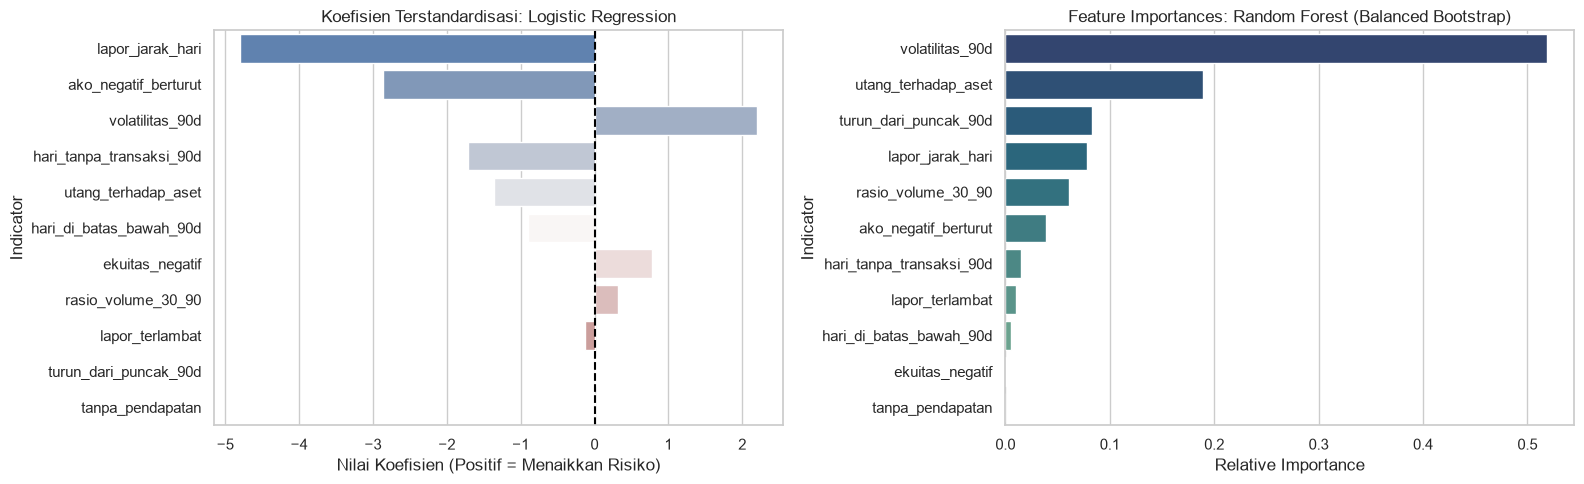

In [8]:
# 8.1 Analisis Koefisien Regresi Logistik dan Feature Importance Random Forest,
# + Menetapkan model_terpilih (dipakai Bagian 9 untuk skor produksi)
rf_model.fit(X, y)  # signature fit(X, y=None) kompatibel di kedua mode

if SUPERVISED_MODE:
    pipe_lr_base.fit(X, y)      # belum pernah di-fit penuh sebelumnya (Bagian 4.1 cuma CV)
    pipe_lr_balanced.fit(X, y)
    lr_coefs = pipe_lr_balanced.named_steps["clf"].coef_[0]
    df_lr_feat = pd.DataFrame({
        "Indicator": feature_cols,
        "Coefficient": lr_coefs,
        "Abs_Weight": np.abs(lr_coefs)
    }).sort_values("Abs_Weight", ascending=False)

    # model_terpilih = model dengan Avg Precision CV tertinggi (Bagian 7.1),
    # BUKAN selalu Random Forest -- lihat catatan Bagian 7.1/9.1.
    model_map = {
        "Baseline Logistic Regression": pipe_lr_base,
        "Logistic Regression (Balanced)": pipe_lr_balanced,
        "Random Forest (Balanced Bootstrap)": rf_model,
    }
    model_terpilih = model_map[best_model_name]
    print(f"Model produksi (Bagian 9): {best_model_name}")
else:
    lr_coefs = None
    df_lr_feat = None
    model_terpilih = rf_model  # SkorAnomaliMahalanobis (fallback unsupervised)
    print("Dilewati: koefisien Logistic Regression (butuh SUPERVISED_MODE=True).")

# Feature Importances Random Forest ATAU SkorAnomaliMahalanobis (keduanya
# punya properti feature_importances_ dengan makna "kontribusi rata-rata")
rf_importances = rf_model.feature_importances_
df_rf_feat = pd.DataFrame({
    "Indicator": feature_cols,
    "Importance": rf_importances
}).sort_values("Importance", ascending=False)

if SUPERVISED_MODE:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.barplot(data=df_lr_feat, x="Coefficient", y="Indicator", ax=axes[0], palette="vlag")
    axes[0].axvline(0, color="black", linestyle="--")
    axes[0].set_title("Koefisien Terstandardisasi: Logistic Regression")
    axes[0].set_xlabel("Nilai Koefisien (Positif = Menaikkan Risiko)")

    sns.barplot(data=df_rf_feat, x="Importance", y="Indicator", ax=axes[1], palette="crest_r")
    axes[1].set_title("Feature Importances: Random Forest (Balanced Bootstrap)")
    axes[1].set_xlabel("Relative Importance")
else:
    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    sns.barplot(data=df_rf_feat, x="Importance", y="Indicator", ax=ax, palette="crest_r")
    ax.set_title("Kontribusi Rata-rata: Skor Anomali Mahalanobis (unsupervised)")
    ax.set_xlabel("Rata-rata |kontribusi| terhadap jarak Mahalanobis")

plt.tight_layout()
plt.show()


---
## 9. Generasi Variabel Keluaran AMBA (Bagian 4 Kamus Variabel)

Sesuai aturan penyajian AMBA:
1. `skor`: Probabilitas risiko mentah dari model.
2. `persentil`: Nilai persentil peringkat risiko (0.0 - 100.0%). Disajikan kepada pengguna.
3. `kategori`:
   - `Rendah`: Persentil 0 - 50
   - `Sedang`: Persentil 50 - 75
   - `Tinggi`: Persentil 75 - 90
   - `Sangat Tinggi`: Persentil 90 - 100
4. `arah_30h`: Perbandingan persentil hari ini vs 30 hari lalu (`naik`, `turun`, `stabil`).
5. `status`:
   - `sudah_ditandai` jika emiten sudah berada di Papan Pemantauan Khusus / Watchlist (`already_flagged == 1`).
   - `dinilai` untuk emiten aktif reguler.
   - `tidak_dapat_dinilai` jika data tidak lengkap.
6. `indikator_dominan` & `kontribusi`: Faktor risiko terbesar yang menyumbang ke skor emiten.

In [9]:
# 9.1 Menghitung Skor, Persentil, Kategori, Tren Arah, dan Kontribusi
# Gunakan snapshot terbaru (2026-09-16) untuk skor live
latest_as_of = df["as_of_date"].max()
df_live = df[df["as_of_date"] == latest_as_of].copy().reset_index(drop=True)

# Gunakan model_terpilih (Bagian 8.1 -- model dengan Avg Precision CV
# tertinggi, atau fallback SkorAnomaliMahalanobis kalau SUPERVISED_MODE=False)
# untuk estimasi skor risiko. BUKAN selalu Random Forest.
X_live = df_live[feature_cols].fillna(X.median())
live_probs = model_terpilih.predict_proba(X_live)[:, 1]

df_live["skor"] = np.round(live_probs, 4)

# Hitung Persentil (0 - 100)
df_live["persentil"] = np.round(df_live["skor"].rank(pct=True) * 100, 1)

# Hitung Kategori Risiko
def assign_risk_category(p):
    if p >= 90.0:
        return "Sangat Tinggi"
    elif p >= 75.0:
        return "Tinggi"
    elif p >= 50.0:
        return "Sedang"
    else:
        return "Rendah"

df_live["kategori"] = df_live["persentil"].apply(assign_risk_category)

# Hitung arah_30h (bandingkan dengan snapshot 30 hari sebelumnya: 2026-08-15)
prev_as_of = "2026-08-15"
df_prev = df[df["as_of_date"] == prev_as_of].copy()
if not df_prev.empty:
    X_prev = df_prev[feature_cols].fillna(X.median())
    prev_probs = model_terpilih.predict_proba(X_prev)[:, 1]
    df_prev["skor_prev"] = prev_probs
    df_prev["persentil_prev"] = df_prev["skor_prev"].rank(pct=True) * 100
    prev_map = dict(zip(df_prev["symbol"], df_prev["persentil_prev"]))
else:
    prev_map = {}

def calculate_direction(row):
    sym = row["symbol"]
    curr_pct = row["persentil"]
    prev_pct = prev_map.get(sym)
    if prev_pct is None:
        return "stabil"
    diff = curr_pct - prev_pct
    if diff > 5.0:
        return "naik"
    elif diff < -5.0:
        return "turun"
    else:
        return "stabil"

df_live["arah_30h"] = df_live.apply(calculate_direction, axis=1)

# Status: memisahkan emiten already_flagged agar tidak mendominasi peringkat utama
def assign_status(row):
    if row["data_complete"] == 0:
        return "tidak_dapat_dinilai"
    elif row["already_flagged"] == 1:
        return "sudah_ditandai"
    else:
        return "dinilai"

df_live["status"] = df_live.apply(assign_status, axis=1)

# Hitung Indikator Dominan dan Kontribusi per Emiten
#
# Kalau model_terpilih adalah Pipeline berisi LogisticRegression (Baseline
# ATAU Balanced -- bisa salah satunya, tergantung mana yang menang di Bagian
# 7.1/8.1): kontribusi dihitung EXACT dari koefisien model_terpilih itu
# sendiri, jadi skor dan penjelasannya konsisten berasal dari model yang sama.
#
# Kalau model_terpilih adalah Random Forest (Balanced Bootstrap): model pohon
# tidak punya kontribusi per-baris bertanda yang murah dihitung exact (butuh
# treeinterpreter/SHAP, di luar requirements.txt saat ini). Dipakai arah
# koefisien Logistic Regression (Balanced) sebagai PROKSI penjelas -- skor
# tetap dari model_terpilih (Random Forest), cuma indikator_dominan/kontribusi
# yang mendekati, bukan exact untuk model itu. Ditandai jelas lewat print di
# bawah supaya tidak disalahpahami sebagai kontribusi Random Forest asli.
if SUPERVISED_MODE:
    clf_terpilih = model_terpilih.named_steps.get("clf") if hasattr(model_terpilih, "named_steps") else None
    if isinstance(clf_terpilih, LogisticRegression):
        scaler_kontribusi = model_terpilih.named_steps["scaler"]
        coefs_kontribusi = clf_terpilih.coef_[0]
    else:
        print(
            f"Catatan: model produksi terpilih ({best_model_name}) adalah model pohon -- "
            "kontribusi/indikator_dominan di bawah memakai arah koefisien Logistic "
            "Regression (Balanced) sebagai PROKSI penjelas, BUKAN dihitung exact dari "
            "model produksi itu sendiri (lihat komentar sel ini)."
        )
        scaler_kontribusi = pipe_lr_balanced.named_steps["scaler"]
        coefs_kontribusi = pipe_lr_balanced.named_steps["clf"].coef_[0]
    X_live_scaled = scaler_kontribusi.transform(X_live)
    contributions_matrix = X_live_scaled * coefs_kontribusi
else:
    contributions_matrix = model_terpilih.mahalanobis_kontribusi(X_live)

dominant_indicators = []
contributions_list = []

for i in range(len(df_live)):
    row_contrib = dict(zip(feature_cols, np.round(contributions_matrix[i], 4)))
    # Cari indikator dengan kontribusi risiko positif terbesar
    pos_contrib = {k: v for k, v in row_contrib.items() if v > 0}
    if pos_contrib:
        dom = max(pos_contrib, key=pos_contrib.get)
    else:
        dom = max(row_contrib, key=row_contrib.get)

    dominant_indicators.append(dom)
    contributions_list.append(row_contrib)

df_live["indikator_dominan"] = dominant_indicators
df_live["kontribusi"] = contributions_list

# Tampilkan Peringkat Risiko Live
live_summary_cols = ["symbol", "company_name", "sector", "sub_sector", "board", "skor", "persentil", "kategori", "arah_30h", "status", "indikator_dominan"]
df_ranked = df_live.sort_values("persentil", ascending=False)
print("=== Peringkat Risiko Emiten AMBA (Live Snapshot) ===")
print(df_ranked[live_summary_cols].to_string(index=False))


=== Peringkat Risiko Emiten AMBA (Live Snapshot) ===
 symbol                               company_name                    sector                              sub_sector        board   skor  persentil      kategori arah_30h         status        indikator_dominan
ALKA.JK                    Alakasa Industrindo Tbk           Basic Materials                         Basic Materials  Development 0.7137      100.0 Sangat Tinggi   stabil sudah_ditandai          volatilitas_90d
UDNG.JK               PT Agro Bahari Nusantara Tbk    Consumer Non-Cyclicals                         Food & Beverage Acceleration 0.4971       98.9 Sangat Tinggi   stabil sudah_ditandai          volatilitas_90d
ASLI.JK                 PT Asri Karya Lestari Tbk.           Infrastructures Heavy Constructions & Civil Engineering  Development 0.3100       97.9 Sangat Tinggi     naik sudah_ditandai          volatilitas_90d
PACK.JK     PT Abadi Nusantara Hijau Investama Tbk           Basic Materials                         Ba

In [10]:
# 9.2 Ekspor Artefak Resmi: scores.json dan backtest.json
output_dir = os.path.join(project_root, "output")
os.makedirs(output_dir, exist_ok=True)

# 1. scores.json -- selalu bisa diekspor, di kedua mode (df_ranked selalu ada)
scores_payload = []
for _, row in df_ranked.iterrows():
    scores_payload.append({
        "symbol": row["symbol"],
        "company_name": row["company_name"],
        "as_of_date": row["as_of_date"],
        "sector": row["sector"],
        "sub_sector": row["sub_sector"],
        "board": row["board"],
        "skor": float(row["skor"]),
        "persentil": float(row["persentil"]),
        "kategori": row["kategori"],
        "arah_30h": row["arah_30h"],
        "status": row["status"],
        "indikator_dominan": row["indikator_dominan"],
        "kontribusi": row["kontribusi"]
    })

scores_file = os.path.join(output_dir, "scores.json")
with open(scores_file, "w", encoding="utf-8") as f:
    json.dump(scores_payload, f, indent=2)

# 2. backtest.json (Evaluasi Bagian 5 Kamus Variabel)
# Precision@20 selalu bisa dihitung (tidak butuh label training, cuma label
# event_category dari 20 peringkat teratas) -- dilaporkan di kedua mode.
# PENTING: harus event_category, BUKAN is_event_90d -- y (Bagian 3) sudah
# didefinisikan dari event_category.notna(), jadi metrik evaluasi apa pun
# di sel ini wajib konsisten dengan definisi target yang sama, bukan diam-diam
# balik ke kolom Kategori-C-saja yang sudah tidak dipakai untuk melatih model.
top_20 = df_ranked.head(20)
prec_at_20 = float(top_20["event_category"].notna().sum() / len(top_20)) if len(top_20) > 0 else 0.0

if SUPERVISED_MODE:
    # Semua metrik di bawah dari model_terpilih (Bagian 8.1/9.1) -- BUKAN
    # selalu Random Forest. df_comp/y_proba_selected/y_pred_selected sudah
    # dihitung untuk model yang sama persis di Bagian 7.1.
    total_events = int(y.sum())
    tp_selected = int(cm[1, 1])
    recall_90h = float(tp_selected / total_events) if total_events > 0 else 0.0
    false_alarms = int(cm[0, 1])

    backtest_payload = {
        "generated_at": datetime.now().isoformat(),
        "model_selected": best_model_name,
        "metrics": {
            "auc": float(np.round(roc_auc_score(y, y_proba_selected), 4)),
            # average_precision = tujuan optimisasi tuning yang sebenarnya
            # (scoring GridSearchCV/RandomizedSearchCV Bagian 5-6), lebih
            # relevan buat sistem peringkat seperti ini dibanding
            # precision/recall pada ambang 0.5 -- lihat catatan Bagian 7.1.
            "average_precision": float(np.round(average_precision_score(y, y_proba_selected), 4)),
            # precision/recall/f1/akurasi_internal_only di bawah dihitung
            # pada ambang_keputusan (Bagian 7.1, dioptimalkan lewat F1),
            # BUKAN 0.5 default sklearn.
            "precision": float(np.round(precision_score(y, y_pred_selected), 4)),
            "recall": float(np.round(recall_score(y, y_pred_selected), 4)),
            "f1_score": float(np.round(f1_score(y, y_pred_selected), 4)),
            "precision_at_20": float(np.round(prec_at_20, 4)),
            "recall_90h": float(np.round(recall_90h, 4)),
            "alarm_palsu": false_alarms,
            "ambang_keputusan": float(np.round(optimal_threshold, 4)),
            "akurasi_internal_only": float(np.round((y == y_pred_selected).mean(), 4))
        },
        "comparison_table": df_comp.to_dict(orient="records")
    }
else:
    # Emiten berkelas positif < 2 -- metrik berbasis label training (AUC,
    # precision, recall, F1, confusion matrix) TIDAK dihitung, dilaporkan
    # null secara eksplisit daripada diisi angka yang tidak berarti apa-apa
    # (lihat Bagian 4.1/6).
    backtest_payload = {
        "generated_at": datetime.now().isoformat(),
        "model_selected": best_model_name,
        "status_validasi": (
            f"BELUM DIVALIDASI SECARA STATISTIK -- cuma {n_pos_groups} emiten dengan "
            f"baris positif (event_category terisi) dari {n_total_groups} emiten yang "
            f"dipantau, di bawah minimum 2 EMITEN BERBEDA yang dibutuhkan validasi "
            f"silang apa pun (bukan minimum 2 baris -- lihat catatan Bagian 3/4.1). "
            f"Perluas cakupan simbol/tanggal (lihat eda_and_feature_engineering.ipynb) "
            f"lalu jalankan ulang notebook ini untuk model supervised yang sah."
        ),
        "metrics": {
            "auc": None,
            "average_precision": None,
            "precision": None,
            "recall": None,
            "f1_score": None,
            "precision_at_20": float(np.round(prec_at_20, 4)),
            "recall_90h": None,
            "alarm_palsu": None,
            "akurasi_internal_only": None
        },
        "comparison_table": None
    }

backtest_file = os.path.join(output_dir, "backtest.json")
with open(backtest_file, "w", encoding="utf-8") as f:
    json.dump(backtest_payload, f, indent=2)

# 3. Simpan binary model -- model_produksi.joblib SELALU model_terpilih (yang
# benar-benar dipakai Bagian 9), plus tiap kandidat individual buat referensi/
# perbandingan (rf_model di sini artinya "kandidat Random Forest", bukan
# berarti dia yang dipakai produksi -- cek model_selected di backtest.json).
if SUPERVISED_MODE:
    joblib.dump(pipe_lr_base, os.path.join(output_dir, "model_baseline_lr.joblib"))
    joblib.dump(pipe_lr_balanced, os.path.join(output_dir, "model_lr_balanced.joblib"))
joblib.dump(rf_model, os.path.join(output_dir, "model_random_forest.joblib"))
joblib.dump(model_terpilih, os.path.join(output_dir, "model_produksi.joblib"))

print("Artefak resmi berhasil diekspor:")
print(f"1. {scores_file} ({os.path.getsize(scores_file):,} bytes)")
print(f"2. {backtest_file} ({os.path.getsize(backtest_file):,} bytes)")
print(f"3. Model binary (.joblib) di {output_dir} -- model produksi: {best_model_name}")
if not SUPERVISED_MODE:
    print(
        "\nPERHATIAN: model yang diekspor adalah fallback unsupervised, bukan "
        "hasil tuning supervised -- backtest.json mencantumkan status_validasi "
        "secara eksplisit. Jangan sajikan metrik AUC/precision/recall di atas "
        "sebagai hasil tuning yang valid ke juri/pembimbing."
    )


Artefak resmi berhasil diekspor:
1. d:\LIMINA-model-train\output\scores.json (79,232 bytes)
2. d:\LIMINA-model-train\output\backtest.json (1,457 bytes)
3. Model binary (.joblib) di d:\LIMINA-model-train\output -- model produksi: Baseline Logistic Regression
